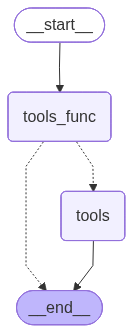

In [2]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper

api_arxiv_wrapper = ArxivAPIWrapper(doc_content_chars_max=500,top_k_results=2)
api_wiki_wrapper = WikipediaAPIWrapper(doc_content_chars_max=500,top_k_results=2)

Arxiv = ArxivQueryRun(api_wrapper=api_arxiv_wrapper)
Wiki = WikipediaQueryRun(api_wrapper=api_wiki_wrapper)

from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

tools = [Arxiv,Wiki,tavily]

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

llm_with_tools = llm.bind_tools(tools=tools)

from langchain_core.messages import AnyMessage
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import add_messages


class State(TypedDict):
    messages : Annotated[list[AnyMessage],add_messages]


def tools_func(state:State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}


from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition
from IPython.display import Image,display

builder = StateGraph(State)

builder.add_node('tools_func',tools_func)
builder.add_node('tools',ToolNode(tools=tools))

builder.add_edge(START,'tools_func')
builder.add_conditional_edges('tools_func',## If the latest message (result) from assistant is a tool call->tool_condition routes to tools
                              # If the latest message (result) from assistant is not a tool call->tool_condition routes to END
                              tools_condition)

builder.add_edge('tools',END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))



In [4]:

from langchain_core.messages import HumanMessage

messages = graph.invoke({"messages":HumanMessage(content="1706.03762")})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_sj3y7WgWvSGvCSR5bXCKlnIG)
 Call ID: call_sj3y7WgWvSGvCSR5bXCKlnIG
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [5]:
from langchain_core.messages import HumanMessage

messages = graph.invoke({"messages":HumanMessage(content="Tell me recent AI news as of 23rd february 2026")})

for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

Tell me recent AI news as of 23rd february 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_c60oQorHfmRMXwybVkgFkV5M)
 Call ID: call_c60oQorHfmRMXwybVkgFkV5M
  Args:
    query: AI news February 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The A.I. Disruption We've Been Waiting for Has Arrived - ny times", "url": "https://www.nytimes.com/2026/02/18/opinion/ai-software.html", "content": "[Skip to content](https://www.nytimes.com/2026/02/18/opinion/ai-software.html#site-content)[Skip to site index](https://www.nytimes.com/2026/02/18/opinion/ai-software.html#site-index)Search & Section Navigation Section Navigation. [Subscribe for $1/week](https://www.nytimes.com/subscription?campaignId=79FKF&source=bar1)[Log in](https://myaccount.nytimes.co

In [7]:
from langchain_core.messages import HumanMessage

messages = graph.invoke({"messages":HumanMessage(content="What is machine learning")})

for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_S9vJAz9UoS4ruEaol7IHk7om)
 Call ID: call_S9vJAz9UoS4ruEaol7IHk7om
  Args:
    query: Machine Learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi
